# 1-Data Prossesing

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [2]:
#load the data
import pandas as pd
dataframe = pd.read_csv('/Users/kazotogbah/Downloads/final_dataset.csv', sep=',')

In [3]:
dataframe

,Unnamed: 0,Winner,R_age,R_Height_cms,R_Reach_cms,R_Stance,R_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_wins,...,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_total_title_bouts,B_longest_win_streak,B_total_rounds_fought,B_avg_SIG_STR_pct,B_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_TD_landed,B_avg_SUB_ATT
0,0,Red,36,182.88,200.66,Orthodox,185,0,2,8,...,3,0,13,17,91,0.620000,0.770,3.040000,0.520000,0.800000
1,1,Red,26,177.80,177.80,Southpaw,145,0,4,4,...,0,0,0,2,37,0.360000,0.490,3.900000,2.710000,0.200000
2,2,Blue,34,200.66,203.20,Orthodox,258,0,1,4,...,0,0,0,2,15,0.480000,0.000,4.480000,0.000000,0.000000
3,3,Red,27,190.50,205.74,Orthodox,170,0,3,7,...,0,0,0,0,0,0.000000,0.000,0.000000,0.000000,0.000000
4,4,Blue,34,177.80,180.34,Orthodox,155,0,3,12,...,1,0,0,1,12,0.430000,0.280,2.680000,1.100000,1.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8903,4449,Red,25,177.80,180.34,Orthodox,145,0,0,0,...,0,0,0,2,5,0.576667,0.000,13.666667,0.000000,0.000000
8904,4450,Blue,29,177.80,187.96,Southpaw,170,0,0,0,...,0,0,0,3,9,0.550000,0.790,18.000000,4.666667,1.000000
8905,4451,Blue,27,190.50,196.00,Orthodox,265,1,0,0,...,0,0,1,0,1,0.250000,0.000,12.000000,0.000000,0.000000
8906,4452,Blue,34,182.88,185.42,Orthodox,170,0,0,0,...,0,0,0,1,6,0.405000,0.520,40.500000,3.500000,0.000000


In [4]:
dataframe.shape

(8908, 56)

In [5]:
dataframe["B_Stance"].value_counts()

Orthodox       6751
Southpaw       1800
Switch          351
Open Stance       5
Switch            1
Name: B_Stance, dtype: int64

In [6]:
cleanup_nums = {"R_Stance":     {"Orthodox": 1, "Southpaw": 2, "Switch":3, "Open Stance":4, "Switch ":3},
                "B_Stance":     {"Orthodox": 1, "Southpaw": 2, "Switch":3, "Open Stance":4, "Switch ":3}}
                

In [7]:
dataframe.replace(cleanup_nums, inplace=True)

In [8]:
dataframe.head()

,Unnamed: 0,Winner,R_age,R_Height_cms,R_Reach_cms,R_Stance,R_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_wins,...,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_total_title_bouts,B_longest_win_streak,B_total_rounds_fought,B_avg_SIG_STR_pct,B_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_TD_landed,B_avg_SUB_ATT
0,0,Red,36,182.88,200.66,1,185,0,2,8,...,3,0,13,17,91,0.62,0.77,3.04,0.52,0.8
1,1,Red,26,177.80,177.80,2,145,0,4,4,...,0,0,0,2,37,0.36,0.49,3.90,2.71,0.2
2,2,Blue,34,200.66,203.20,1,258,0,1,4,...,0,0,0,2,15,0.48,0.00,4.48,0.00,0.0
3,3,Red,27,190.50,205.74,1,170,0,3,7,...,0,0,0,0,0,0.00,0.00,0.00,0.00,0.0
4,4,Blue,34,177.80,180.34,1,155,0,3,12,...,1,0,0,1,12,0.43,0.28,2.68,1.10,1.6


In [9]:
dataframe['B_stance'] = dataframe['B_Stance'].astype(float)

In [10]:
dataframe['R_stance'] = dataframe['R_Stance'].astype(float)

In [11]:
cols=['Unnamed: 0','B_fighter','R_fighter','R_ev', 'B_ev', 'R_odds', 'B_odds']
dataset=dataframe.drop( cols,axis=1)

In [12]:
dataset.head()

,Winner,R_age,R_Height_cms,R_Reach_cms,R_Stance,R_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_wins,R_losses,...,B_total_title_bouts,B_longest_win_streak,B_total_rounds_fought,B_avg_SIG_STR_pct,B_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_TD_landed,B_avg_SUB_ATT,B_stance,R_stance
0,Red,36,182.88,200.66,1,185,0,2,8,7,...,13,17,91,0.62,0.77,3.04,0.52,0.8,2.0,1.0
1,Red,26,177.80,177.80,2,145,0,4,4,0,...,0,2,37,0.36,0.49,3.90,2.71,0.2,1.0,2.0
2,Blue,34,200.66,203.20,1,258,0,1,4,2,...,0,2,15,0.48,0.00,4.48,0.00,0.0,1.0,1.0
3,Red,27,190.50,205.74,1,170,0,3,7,2,...,0,0,0,0.00,0.00,0.00,0.00,0.0,3.0,1.0
4,Blue,34,177.80,180.34,1,155,0,3,12,7,...,0,1,12,0.43,0.28,2.68,1.10,1.6,1.0,1.0


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8908 entries, 0 to 8907
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Winner                        8908 non-null   object 
 1   R_age                         8908 non-null   int64  
 2   R_Height_cms                  8908 non-null   float64
 3   R_Reach_cms                   8908 non-null   float64
 4   R_Stance                      8908 non-null   int64  
 5   R_Weight_lbs                  8908 non-null   int64  
 6   R_current_lose_streak         8908 non-null   int64  
 7   R_current_win_streak          8908 non-null   int64  
 8   R_wins                        8908 non-null   int64  
 9   R_losses                      8908 non-null   int64  
 10  R_draw                        8908 non-null   int64  
 11  R_win_by_Decision_Majority    8908 non-null   int64  
 12  R_win_by_Decision_Split       8908 non-null   int64  
 13  R_w

In [14]:
dataset.shape

(8908, 51)

In [15]:
dataset

,Winner,R_age,R_Height_cms,R_Reach_cms,R_Stance,R_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_wins,R_losses,...,B_total_title_bouts,B_longest_win_streak,B_total_rounds_fought,B_avg_SIG_STR_pct,B_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_TD_landed,B_avg_SUB_ATT,B_stance,R_stance
0,Red,36,182.88,200.66,1,185,0,2,8,7,...,13,17,91,0.620000,0.770,3.040000,0.520000,0.800000,2.0,1.0
1,Red,26,177.80,177.80,2,145,0,4,4,0,...,0,2,37,0.360000,0.490,3.900000,2.710000,0.200000,1.0,2.0
2,Blue,34,200.66,203.20,1,258,0,1,4,2,...,0,2,15,0.480000,0.000,4.480000,0.000000,0.000000,1.0,1.0
3,Red,27,190.50,205.74,1,170,0,3,7,2,...,0,0,0,0.000000,0.000,0.000000,0.000000,0.000000,3.0,1.0
4,Blue,34,177.80,180.34,1,155,0,3,12,7,...,0,1,12,0.430000,0.280,2.680000,1.100000,1.600000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8903,Red,25,177.80,180.34,1,145,0,0,0,0,...,0,2,5,0.576667,0.000,13.666667,0.000000,0.000000,1.0,1.0
8904,Blue,29,177.80,187.96,2,170,0,0,0,0,...,0,3,9,0.550000,0.790,18.000000,4.666667,1.000000,1.0,2.0
8905,Blue,27,190.50,196.00,1,265,1,0,0,1,...,1,0,1,0.250000,0.000,12.000000,0.000000,0.000000,1.0,1.0
8906,Blue,34,182.88,185.42,1,170,0,0,0,0,...,0,1,6,0.405000,0.520,40.500000,3.500000,0.000000,1.0,1.0


In [16]:
y=pd.DataFrame(dataset['Winner'])

In [17]:
y.shape

(8908, 1)

In [18]:
X = dataset.drop(dataset.columns[[0]],axis=1)

In [19]:
X.shape

(8908, 50)

In [20]:
X

,R_age,R_Height_cms,R_Reach_cms,R_Stance,R_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_wins,R_losses,R_draw,...,B_total_title_bouts,B_longest_win_streak,B_total_rounds_fought,B_avg_SIG_STR_pct,B_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_TD_landed,B_avg_SUB_ATT,B_stance,R_stance
0,36,182.88,200.66,1,185,0,2,8,7,0,...,13,17,91,0.620000,0.770,3.040000,0.520000,0.800000,2.0,1.0
1,26,177.80,177.80,2,145,0,4,4,0,0,...,0,2,37,0.360000,0.490,3.900000,2.710000,0.200000,1.0,2.0
2,34,200.66,203.20,1,258,0,1,4,2,0,...,0,2,15,0.480000,0.000,4.480000,0.000000,0.000000,1.0,1.0
3,27,190.50,205.74,1,170,0,3,7,2,0,...,0,0,0,0.000000,0.000,0.000000,0.000000,0.000000,3.0,1.0
4,34,177.80,180.34,1,155,0,3,12,7,1,...,0,1,12,0.430000,0.280,2.680000,1.100000,1.600000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8903,25,177.80,180.34,1,145,0,0,0,0,0,...,0,2,5,0.576667,0.000,13.666667,0.000000,0.000000,1.0,1.0
8904,29,177.80,187.96,2,170,0,0,0,0,0,...,0,3,9,0.550000,0.790,18.000000,4.666667,1.000000,1.0,2.0
8905,27,190.50,196.00,1,265,1,0,0,1,0,...,1,0,1,0.250000,0.000,12.000000,0.000000,0.000000,1.0,1.0
8906,34,182.88,185.42,1,170,0,0,0,0,0,...,0,1,6,0.405000,0.520,40.500000,3.500000,0.000000,1.0,1.0


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [22]:
X_train.shape

(7126, 50)

In [23]:
y_train.shape

(7126, 1)

In [24]:
# Scale all features
from sklearn import preprocessing 
#Normalize data
std_scale = preprocessing.StandardScaler().fit(X_train) 
X_train_scaled = std_scale.transform(X_train)
X_test_scaled = std_scale.transform(X_test)

In [25]:
X_train_scaled.shape

(7126, 50)

In [26]:
X_test_scaled.shape

(1782, 50)

# Random Forest Classifier - Base Model

In [42]:
# Use the RandomForestClassifier in sklearn. Fit your model on the training data.
from sklearn.ensemble import RandomForestClassifier
base_model = RandomForestClassifier()
base_model.fit(X_train_scaled,y_train)

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  after removing the cwd from sys.path.


RandomForestClassifier()

In [43]:
# Use the fitted model to predict on test data. Use the .predict_proba() and the .predict()
# methods to get predicted probabilities as well as predicted classes.

from sklearn.metrics import accuracy_score
y_pred= base_model.predict(X_test_scaled) 
y_pred_prob=base_model.predict_proba(X_test_scaled) # [:,1] 

accuracy_score(y_test, y_pred)

0.5718294051627385

In [44]:
y_pred

array(['Blue', 'Red', 'Red', ..., 'Red', 'Red', 'Blue'], dtype=object)

In [45]:
# Identify the top 5 features. Feel free to print a list OR to make a plot.
df={'Predictors':X_train.columns, 'FI':base_model.fit(X_train_scaled,y_train).feature_importances_}
data_FI=pd.DataFrame(df)

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


In [46]:
FI_class = data_FI.sort_values(by='FI',ascending=0)
print(FI_class.head(10))

              Predictors        FI
24                 B_age  0.045749
19     R_avg_SIG_STR_pct  0.045007
21  R_avg_SIG_STR_landed  0.044717
0                  R_age  0.044060
45  B_avg_SIG_STR_landed  0.043764
43     B_avg_SIG_STR_pct  0.042920
26           B_Reach_cms  0.037687
2            R_Reach_cms  0.037466
44          B_avg_TD_pct  0.034327
20          R_avg_TD_pct  0.033544


In [47]:
FI = FI_class.head(20)
FI_1=FI.sort_values(by='FI',ascending=True)

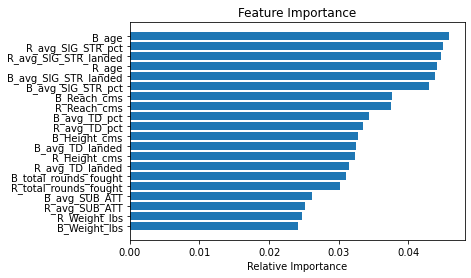

In [48]:
plt.title("Feature Importance")
plt.barh(FI_1.Predictors,FI_1.FI)
plt.xlabel("Relative Importance")
plt.show()

# LinearSVM Classifier - Base Model

In [27]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification


In [28]:
base_model2=LinearSVC()
base_model2.fit(X_train_scaled,y_train)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
/opt/anaconda3/lib/python3.7/site-packages/sklearn/svm/_base.py:977: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVC()

In [29]:
# Use the fitted model to predict on test data. 
# methods to get predicted probabilities as well as predicted classes.

from sklearn.metrics import accuracy_score
y_pred= base_model2.predict(X_test_scaled) 
accuracy_score(y_test, y_pred)

0.590347923681257

In [30]:
# Accuracy for train data
from sklearn.metrics import accuracy_score
y_predtrain= base_model2.predict(X_train_scaled) 
accuracy_score(y_train, y_predtrain)

0.6049677238282346

In [31]:
feat_df=pd.Series(base_model2.coef_[0],index=X_train.columns)

In [32]:
data_FI=pd.DataFrame(feat_df)
data_FI.columns =['FI'] 

In [33]:
FI_class = data_FI.sort_values(by='FI',ascending=0)
print(FI_class.head(10))

                                   FI
B_wins                       0.223807
R_Weight_lbs                 0.219008
B_age                        0.125152
R_Reach_cms                  0.112699
R_total_rounds_fought        0.106388
B_losses                     0.089043
R_win_by_KO/TKO              0.085362
B_Height_cms                 0.070140
R_longest_win_streak         0.067296
R_win_by_Decision_Unanimous  0.063642


In [34]:
FI = FI_class.head(20)
FI_1=FI.sort_values(by='FI',ascending=True)

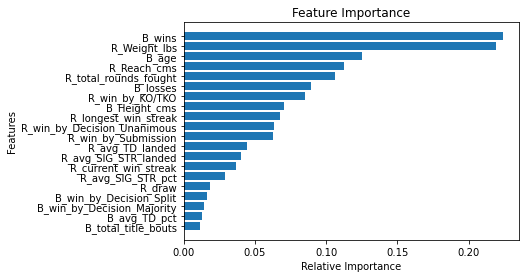

In [35]:
plt.title("Feature Importance")
plt.barh(FI_1.index,FI_1.FI)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()

We see that B_Stance is predominant in predicting the outcome of the fight

# Support Vector Machine Classifier + Linear Kernel + Random Search

In [36]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [37]:
#  Use SVC from sklearn with kernel = "linear". Run the random search using the following 
#create a dictionary of parameters 
param_grid = {"C": np.arange(0.01, 10, 0.2),
              "gamma" : [1,0.1,0.001,0.0001]}
model3= SVC(kernel="linear")
# Create gridsearch object with various combinations of parameters
grid_model3= RandomizedSearchCV(model3, param_grid, cv = 5, scoring =None, refit = True, n_jobs=-1, verbose = 0)

In [38]:
grid_model3.fit(X_train_scaled,y_train)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


RandomizedSearchCV(cv=5, estimator=SVC(kernel='linear'), n_jobs=-1,
                   param_distributions={'C': array([0.01, 0.21, 0.41, 0.61, 0.81, 1.01, 1.21, 1.41, 1.61, 1.81, 2.01,
       2.21, 2.41, 2.61, 2.81, 3.01, 3.21, 3.41, 3.61, 3.81, 4.01, 4.21,
       4.41, 4.61, 4.81, 5.01, 5.21, 5.41, 5.61, 5.81, 6.01, 6.21, 6.41,
       6.61, 6.81, 7.01, 7.21, 7.41, 7.61, 7.81, 8.01, 8.21, 8.41, 8.61,
       8.81, 9.01, 9.21, 9.41, 9.61, 9.81]),
                                        'gamma': [1, 0.1, 0.001, 0.0001]})

In [39]:
# Identify the best performing model
grid_model3.best_estimator_

SVC(C=4.8100000000000005, gamma=0.0001, kernel='linear')

In [40]:
# Use the best estimator model to predict on test data. Use the .predict() method to get the predicted classes.
from sklearn.svm import SVC
lin_svc=SVC(C=4.8100000000000005, gamma=0.0001, kernel='linear')
lin_svc.fit(X_train_scaled,y_train)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:73: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


SVC(C=4.8100000000000005, gamma=0.0001, kernel='linear')

In [41]:
# accuracy test data
from sklearn.metrics import accuracy_score
y_pred3= lin_svc.predict(X_test_scaled) 
accuracy_score(y_test, y_pred3)

0.5763187429854096

In [42]:
# accuracy train data
from sklearn.metrics import accuracy_score
y_pred3train= lin_svc.predict(X_train_scaled) 
accuracy_score(y_train, y_pred3train)

0.6023014313780523

In [50]:
feat_df=pd.Series(lin_svc.coef_[0],index=X_train.columns)
data_FI=pd.DataFrame(feat_df)
data_FI.columns =['FI'] 
FI_class = data_FI.sort_values(by='FI',ascending=0)
print(FI_class.head(10))

                                   FI
R_Weight_lbs                 0.601334
B_age                        0.416599
R_Reach_cms                  0.352726
B_wins                       0.332107
R_total_rounds_fought        0.318392
B_losses                     0.285836
B_Height_cms                 0.247102
R_win_by_KO/TKO              0.226687
R_win_by_Decision_Unanimous  0.161519
R_win_by_Submission          0.154853


In [51]:
FI = FI_class.head(20)
FI_1=FI.sort_values(by='FI',ascending=True)

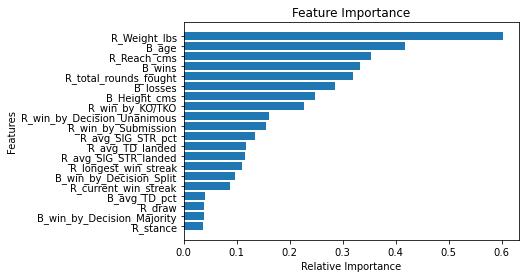

In [52]:
plt.title("Feature Importance")
plt.barh(FI_1.index,FI_1.FI)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()